In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
foldername = '/home/edavenport/analysis/TPOSE6_Sensitivity/apr2013/'

In [60]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np

data_dir = '/data/SO3/edavenport/tpose6/apr2013/run_sens_surface/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(0,itPerFile*num_diags,itPerFile) # adjoint sensitivity will start at 0 and go to 1 lag (1 interval less than total number of timesteps)
prefix = ['ADJtauy','ADJswdown','ADJhflux','ADJvvel','ADJuvel']
# when prefix is not set, this will read all available files 
# have to ignore unkown vars until we have an available_diagnostics.log that includes ADJrhoinsitu
tpose_ds_surf = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,prefix=prefix,iters=intervals,ref_date='2013-04-01',delta_t=1200,ignore_unknown_vars=True)
tpose_ds_surf['XC'] = tpose_ds_surf.XC.astype(float)
tpose_ds_surf['YC'] = tpose_ds_surf.YC.astype(float)
tpose_ds_surf['Z'] = tpose_ds_surf.Z.astype(float)
tpose_ds_surf['XG'] = tpose_ds_surf.XG.astype(float)
tpose_ds_surf['YG'] = tpose_ds_surf.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/apr2013/run_sens_EUC/'

# have to ignore unkown vars until we have an available_diagnostics.log that includes ADJrhoinsitu
tpose_ds_EUC = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,prefix=prefix,iters=intervals,ref_date='2013-04-01',delta_t=1200,ignore_unknown_vars=True)
tpose_ds_EUC['XC'] = tpose_ds_EUC.XC.astype(float)
tpose_ds_EUC['YC'] = tpose_ds_EUC.YC.astype(float)
tpose_ds_EUC['Z'] = tpose_ds_EUC.Z.astype(float)
tpose_ds_EUC['XG'] = tpose_ds_EUC.XG.astype(float)
tpose_ds_EUC['YG'] = tpose_ds_EUC.YG.astype(float)

### Select Region

In [63]:
tpose_ds_EUC.ADJvvel

<xarray.DataArray 'ADJvvel' (time: 122, Z: 66, YG: 61, XC: 540)> Size: 1GB
dask.array<getitem, shape=(122, 66, 61, 540), dtype=float32, chunksize=(1, 66, 61, 540), chunktype=numpy.ndarray>
Coordinates: (12/13)
  * time     (time) datetime64[ns] 976B 2013-04-01 2013-04-02 ... 2013-07-31
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
  * YG       (YG) float64 488B -5.0 -4.833 -4.667 -4.5 ... 4.5 4.667 4.833 5.0
  * XC       (XC) float64 4kB 170.1 170.2 170.4 170.6 ... 259.6 259.8 259.9
    dxG      (YG, XC) >f4 132kB dask.array<chunksize=(61, 540), meta=np.ndarray>
    dyC      (YG, XC) >f4 132kB dask.array<chunksize=(61, 540), meta=np.ndarray>
    ...       ...
    drF      (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    PHrefC   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    hFacS    (Z, YG, XC) >f4 9MB dask.array<chunksize=(66, 61, 540), meta=np.ndarray>
    maskS    (Z, YG, XC) bool 2MB dask.array<chunksize=(66, 61, 540), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    iter     (time) int64 976B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:  ADJvvel
    long_name:      dJ/dV: Sensitivity to meridional velocity
    units:          dJ/(m/s)
    mate:           ADJuvel

In [62]:
# tpose_ds.ADJetan is t, xc, YG
lat_min = -5
lat_max = 5
lon_min = 170 #170E
lon_max = 260 #100W

tpose_ds_EUC = tpose_ds_EUC.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))
tpose_ds_surf = tpose_ds_surf.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))

In [188]:
var_name = 'ADJuvel'
sub_folder = var_name + '/'
fig_str = var_name + '_3000m'
lat_dim = 'YC'
lon_dim = 'XG'

### Temporal Demean and Detrend

In [174]:
from scipy.signal import detrend

surf_detrend = detrend(tpose_ds_surf[var_name], axis=0)
EUC_detrend = detrend(tpose_ds_EUC[var_name], axis=0)


# copy into data array
surf_detrend = xr.DataArray(surf_detrend, coords=tpose_ds_surf[var_name].coords, dims=tpose_ds_surf[var_name].dims)
EUC_detrend = xr.DataArray(EUC_detrend, coords=tpose_ds_EUC[var_name].coords, dims=tpose_ds_EUC[var_name].dims)


### Filter for Desired Frequency Range

In [215]:
from scipy.signal import butter, sosfiltfilt, detrend

# demean
surf_anom = surf_detrend - surf_detrend.mean(dim='time')
EUC_anom = EUC_detrend - EUC_detrend.mean(dim='time')

surf_anom = surf_anom.sel(Z=-3000,method='nearest')
EUC_anom = EUC_anom.sel(Z=-3000,method='nearest')

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/3*fs) #  (1 cycle /10 days) * (1 day/86400 second)
# lowF = (1/20*fs) #  (1 cycle /30 days) * (1 day/86400 second)
# cutoff = np.array([lowF, highF])
order = 4
# sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')
sos = butter(order, highF, 'lowpass', fs=fs, output='sos')

surf_bandpass = sosfiltfilt(sos, detrend(surf_anom,axis=0), axis=0)
EUC_bandpass = sosfiltfilt(sos, detrend(EUC_anom,axis=0), axis=0)

temp = surf_anom.copy(deep=True)
temp.data = surf_bandpass
surf_bandpass = temp

temp = EUC_anom.copy(deep=True)
temp.data = EUC_bandpass
EUC_bandpass = temp

surf_bandpass = surf_bandpass.compute()
EUC_bandpass = EUC_bandpass.compute()

In [216]:
# simpler: manually select +y and -y
pos = surf_bandpass.where(surf_bandpass[lat_dim] >= 1e-14, drop=True)
neg = surf_bandpass.where(surf_bandpass[lat_dim] <= 1e-13, drop=True)

# flip neg to align with pos
neg_flipped = neg.values[:,::-1,:]

# symmetric
sym = 0.5 * (pos.values + neg_flipped)
# antisymmetric
anti = 0.5 * (pos.values - neg_flipped)

bandpass_sym = xr.DataArray(sym,coords=pos.coords,dims=pos.dims)
bandpass_anti = xr.DataArray(anti,coords=pos.coords,dims=pos.dims)
bandpass_sym_surf = bandpass_sym.mean(dim=lat_dim)
bandpass_anti_surf = bandpass_anti.mean(dim=lat_dim)
bandpass_anom_surf = surf_bandpass.mean(dim=lat_dim)

# simpler: manually select +y and -y
pos = EUC_bandpass.where(EUC_bandpass[lat_dim] >= 1e-14, drop=True)
neg = EUC_bandpass.where(EUC_bandpass[lat_dim] <= 1e-13, drop=True)

# flip neg to align with pos
neg_flipped = neg.values[:,::-1,:]

# symmetric
sym = 0.5 * (pos.values + neg_flipped)
# antisymmetric
anti = 0.5 * (pos.values - neg_flipped)

bandpass_sym = xr.DataArray(sym,coords=pos.coords,dims=pos.dims)
bandpass_anti = xr.DataArray(anti,coords=pos.coords,dims=pos.dims)
bandpass_sym_EUC = bandpass_sym.mean(dim=lat_dim)
bandpass_anti_EUC = bandpass_anti.mean(dim=lat_dim)
bandpass_anom_EUC = EUC_bandpass.mean(dim=lat_dim)

#### k-w plots

In [217]:
window_t = np.hanning(bandpass_anom_surf.shape[0])
window_x = np.hanning(bandpass_anom_surf.shape[1])
window_2d = np.outer(window_t, window_x)
windowed = bandpass_anom_surf * window_2d
sym_windowed = bandpass_sym_surf * window_2d
anti_windowed = bandpass_anti_surf * window_2d

# # -----------------------------
# # 2D FFT
# # -----------------------------
vvel_fft = np.fft.fft2(windowed)
vvel_fft = np.fft.fftshift(vvel_fft, axes=(0,1))  # shift time and lon axes
Nt = windowed.shape[0]
Nx = windowed.shape[1]
P_surf = np.abs(vvel_fft)**2 / (Nt*Nx)

vvel_sym_fft = np.fft.fft2(sym_windowed)
vvel_sym_fft = np.fft.fftshift(vvel_sym_fft, axes=(0,1))  # shift time and lon axes
P_sym_surf = np.abs(vvel_sym_fft)**2 / (Nt*Nx)

vvel_anti_fft = np.fft.fft2(anti_windowed)
vvel_anti_fft = np.fft.fftshift(vvel_anti_fft, axes=(0,1))  # shift time and lon axes
P_anti_surf = np.abs(vvel_anti_fft)**2 / (Nt*Nx)

In [218]:
window_t = np.hanning(bandpass_anom_EUC.shape[0])
window_x = np.hanning(bandpass_anom_EUC.shape[1])
window_2d = np.outer(window_t, window_x)
windowed = bandpass_anom_EUC * window_2d
sym_windowed = bandpass_sym_EUC * window_2d
anti_windowed = bandpass_anti_EUC * window_2d

# # -----------------------------
# # 2D FFT
# # -----------------------------
vvel_fft = np.fft.fft2(windowed)
vvel_fft = np.fft.fftshift(vvel_fft, axes=(0,1))  # shift time and lon axes
Nt = windowed.shape[0]
Nx = windowed.shape[1]
P_EUC = np.abs(vvel_fft)**2 / (Nt*Nx)

vvel_sym_fft = np.fft.fft2(sym_windowed)
vvel_sym_fft = np.fft.fftshift(vvel_sym_fft, axes=(0,1))  # shift time and lon axes
P_sym_EUC = np.abs(vvel_sym_fft)**2 / (Nt*Nx)

vvel_anti_fft = np.fft.fft2(anti_windowed)
vvel_anti_fft = np.fft.fftshift(vvel_anti_fft, axes=(0,1))  # shift time and lon axes
P_anti_EUC = np.abs(vvel_anti_fft)**2 / (Nt*Nx)

In [219]:
dx = np.mean(np.diff(tpose_ds_surf[var_name][lon_dim]))  # in units of degrees
dt_ns = np.mean(np.diff(tpose_ds_surf[var_name].time))              # timedelta64[ns]
dt = dt_ns / np.timedelta64(1, 'D') # convert to float in days

print(dt)    # 1 day
print(dx)    # 1/6 degree

# wavenumber / frequency axes
kx = -np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))        # deg^-1
omega = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt)) # cycles/day


1.0
0.16666666666666666


In [220]:
# -----------------------------
# Normalize for real signal
# -----------------------------
# double all non-zero, non-Nyquist frequencies along time
nonzero_idx = np.where((omega != 0) & (omega != omega.max()))[0]

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
omega_pos = omega[pos_idx]

P_EUC[nonzero_idx, :] *= 2
P_pos_EUC = P_EUC[pos_idx, :]
P_surf[nonzero_idx, :] *= 2
P_pos_surf = P_surf[pos_idx, :]

# Create xarray for plotting
P_da_surf = xr.DataArray(P_pos_surf, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})
P_da_EUC = xr.DataArray(P_pos_EUC, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})
# -----------------------------
# Select only positive omega
# -----------------------------
P_sym_surf[nonzero_idx, :] *= 2
P_pos_surf = P_sym_surf[pos_idx, :]
P_sym_EUC[nonzero_idx, :] *= 2
P_pos_EUC = P_sym_EUC[pos_idx, :]

# Create xarray for plotting
P_da_sym_surf = xr.DataArray(P_pos_surf, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})
P_da_sym_EUC = xr.DataArray(P_pos_EUC, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

P_anti_surf[nonzero_idx, :] *= 2
P_pos_surf = P_anti_surf[pos_idx, :]
P_anti_EUC[nonzero_idx, :] *= 2
P_pos_EUC = P_anti_EUC[pos_idx, :]
# -----------------------------
# Select only positive omega
# -----------------------------
# Create xarray for plotting
P_da_anti_surf = xr.DataArray(P_pos_surf, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})
P_da_anti_EUC = xr.DataArray(P_pos_EUC, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

In [221]:
# # --- Dispersion relations --- in rad/s
def omega_kelvin_fn(k, c): 
#     # Kelvin waves exist for eastward (positive k) only
    omega = np.zeros_like(k)
    omega[k>=0] = c*k[k>=0]
    omega[k<0] = np.nan  # optional: don't plot Kelvin for negative k
    return omega

def omega_yanai(k, c, beta): 
    return 0.5*(c*k - np.sqrt((c*k)**2 + 4*beta*c))

def omega_yanai_east(k, c, beta): 
    return 0.5*(c*k + np.sqrt((c*k)**2 + 4*beta*c))

def omega_rossby_fn(k, n, c, beta): 
    return - beta*k / (k**2 + (2*n + 1)*beta/c)

def omega_IG(k, n, c, beta): 
    return np.sqrt(c**2 * k**2 + (2*n + 1)*beta*c)

In [222]:
# -----------------------------
# Physical constants
# -----------------------------
g = 9.81            # m/s^2
beta = 2.3e-11      # 1/(m s)
c1 = 2.5
c2 = 1.4
deg2m = 111320      # m per degree at equator
c_barotropic = np.sqrt(9.81*4000)  # m/s

In [223]:
# deg2m = 111320      # m per degree at equator
# k_rad = 2*np.pi * kx / deg2m  # convert to rad/m

# # --- Plotting ---
# plt.figure(figsize=(6,6))

# # Kelvin (eastward only)
# plt.plot(kx, omega_kelvin_fn(k_rad, c1)*86400, label="Kelvin n=-1")

# # Yanai
# plt.plot(kx, omega_yanai(k_rad, c1, beta)*86400, label="Yanai n=0 (west)")
# plt.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400, label="Yanai n=0 (east)")

# # Rossby n=1..3
# for n in [1,2,3]:
#     plt.plot(kx, omega_rossby_fn(k_rad, n, c1, beta)*86400, label=f"Rossby n={n}")

# # IG n=1..3
# for n in [1,2,3]:
#     plt.plot(kx, omega_IG(k_rad, n, c1, beta)*86400, label=f"IG n={n}")

# plt.xlabel("Zonal wavenumber k [deg$^{-1}$] (positive = east, negative = west)")
# plt.ylabel("Frequency ω [rad/day]")
# plt.title("Equatorial Wave Dispersion Curves (first baroclinic mode)")
# plt.legend()
# plt.xlim(-1, 1)
# plt.ylim(0, 1.0)
# plt.grid(True)
# plt.show()

In [224]:
from matplotlib.colors import LogNorm
min = 3
max = 7
log_levels = np.logspace(min, max, 100)
norm = LogNorm(vmin=10**min,vmax=10**max)
ticks = np.logspace(min, max, 4)

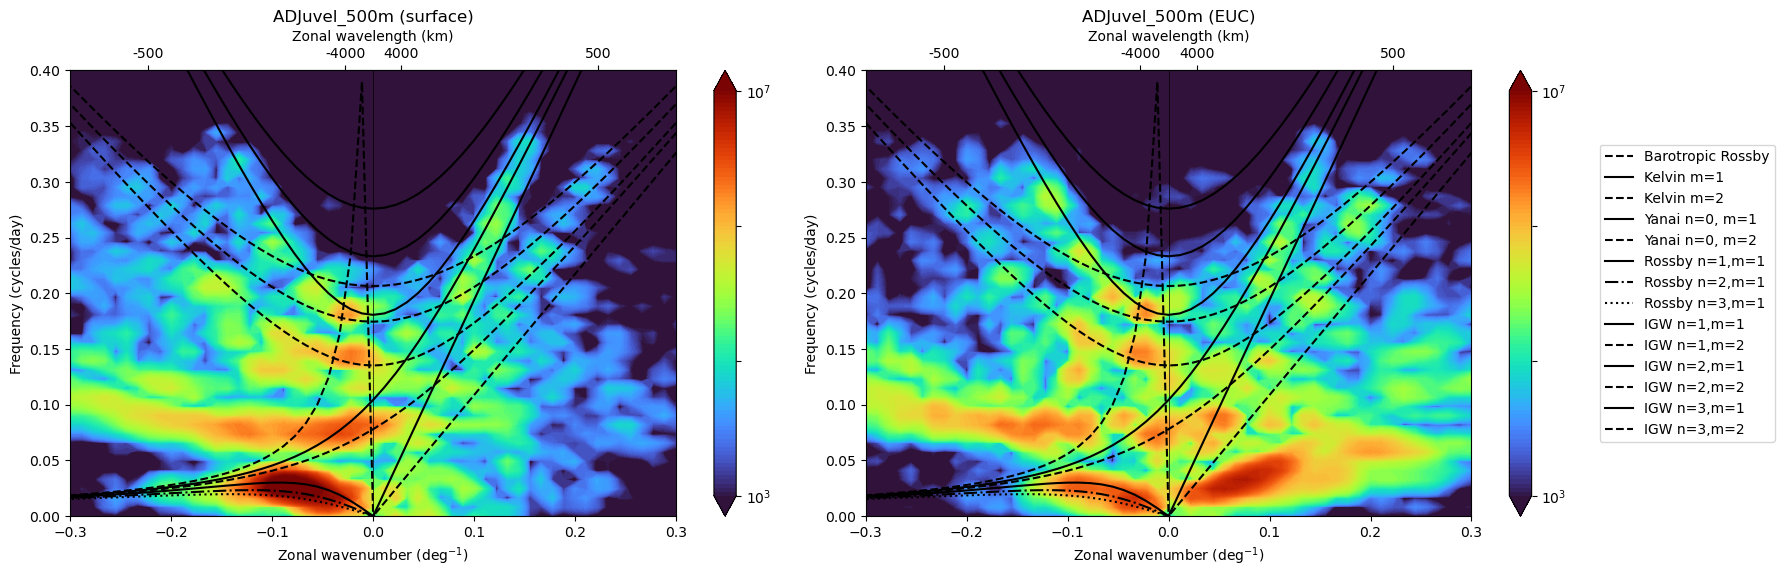

In [225]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s


fig, axes = plt.subplots(figsize=(18,6),ncols=2)
cf = P_da_surf.plot.contourf(ax=axes[0],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)
cf = P_da_EUC.plot.contourf(ax=axes[1],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

for ax in axes.flatten():
    ax.set_ylabel('Frequency (cycles/day)')
    ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
    # Overlay dispersion curves
    ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='k', linestyle='--', label='Barotropic Rossby')
    ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='k', label='Kelvin m=1')
    ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='k', linestyle='--',label='Kelvin m=2')
    ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='k', label='Yanai n=0, m=1')
    ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='Yanai n=0, m=2')
    ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='Rossby n=1,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', linestyle='-.', label='Rossby n=2,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', linestyle=':', label='Rossby n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=1,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=1,m=2')
    ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=2,m=1')
    ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=2,m=2')
    ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=3,m=2')
    ax.axvline(0, color='k',label='_nolabel',lw=0.5)
    # Manually set secondary x-axis ticks
    km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
    kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
    # Set secondary axis manually with fixed tick positions
    secax = ax.secondary_xaxis('top')
    secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
    secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
    secax.set_xlabel('Zonal wavelength (km)')

    ax.set_xlim(-0.3,0.3)
    ax.set_ylim(0,0.4)

axes[0].set_title(fig_str + ' (surface)')
axes[1].set_title(fig_str + ' (EUC)')
axes[1].legend(bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
fig.savefig(foldername + 'k_omega_spectrum_' + fig_str + '.png', dpi=300)

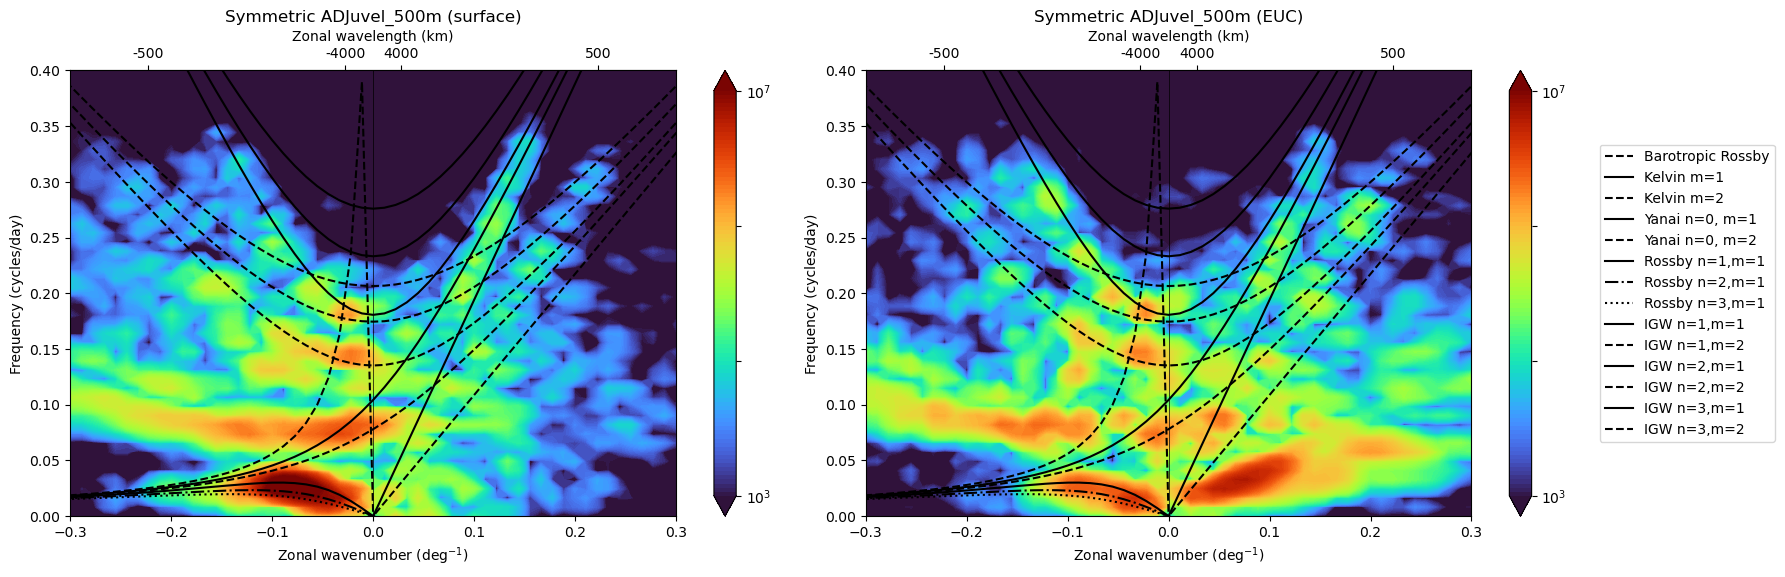

In [226]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s


fig, axes = plt.subplots(figsize=(18,6),ncols=2)
cf = P_da_sym_surf.plot.contourf(ax=axes[0],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)
cf = P_da_sym_EUC.plot.contourf(ax=axes[1],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

for ax in axes.flatten():
    ax.set_ylabel('Frequency (cycles/day)')
    ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
    # Overlay dispersion curves
    ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='k', linestyle='--', label='Barotropic Rossby')
    ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='k', label='Kelvin m=1')
    ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='k', linestyle='--',label='Kelvin m=2')
    ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='k', label='Yanai n=0, m=1')
    ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='Yanai n=0, m=2')
    ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='Rossby n=1,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', linestyle='-.', label='Rossby n=2,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', linestyle=':', label='Rossby n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=1,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=1,m=2')
    ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=2,m=1')
    ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=2,m=2')
    ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=3,m=2')
    ax.axvline(0, color='k',label='_nolabel',lw=0.5)
    # Manually set secondary x-axis ticks
    km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
    kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
    # Set secondary axis manually with fixed tick positions
    secax = ax.secondary_xaxis('top')
    secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
    secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
    secax.set_xlabel('Zonal wavelength (km)')
    ax.set_xlim(-0.3,0.3)
    ax.set_ylim(0,0.4)

axes[0].set_title(f'Symmetric ' + fig_str + ' (surface)')
axes[1].set_title(f'Symmetric ' + fig_str + ' (EUC)')
axes[1].legend(bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
fig.savefig(foldername + 'k_omega_spectrum_' + fig_str + 'symmetric.png', dpi=300)

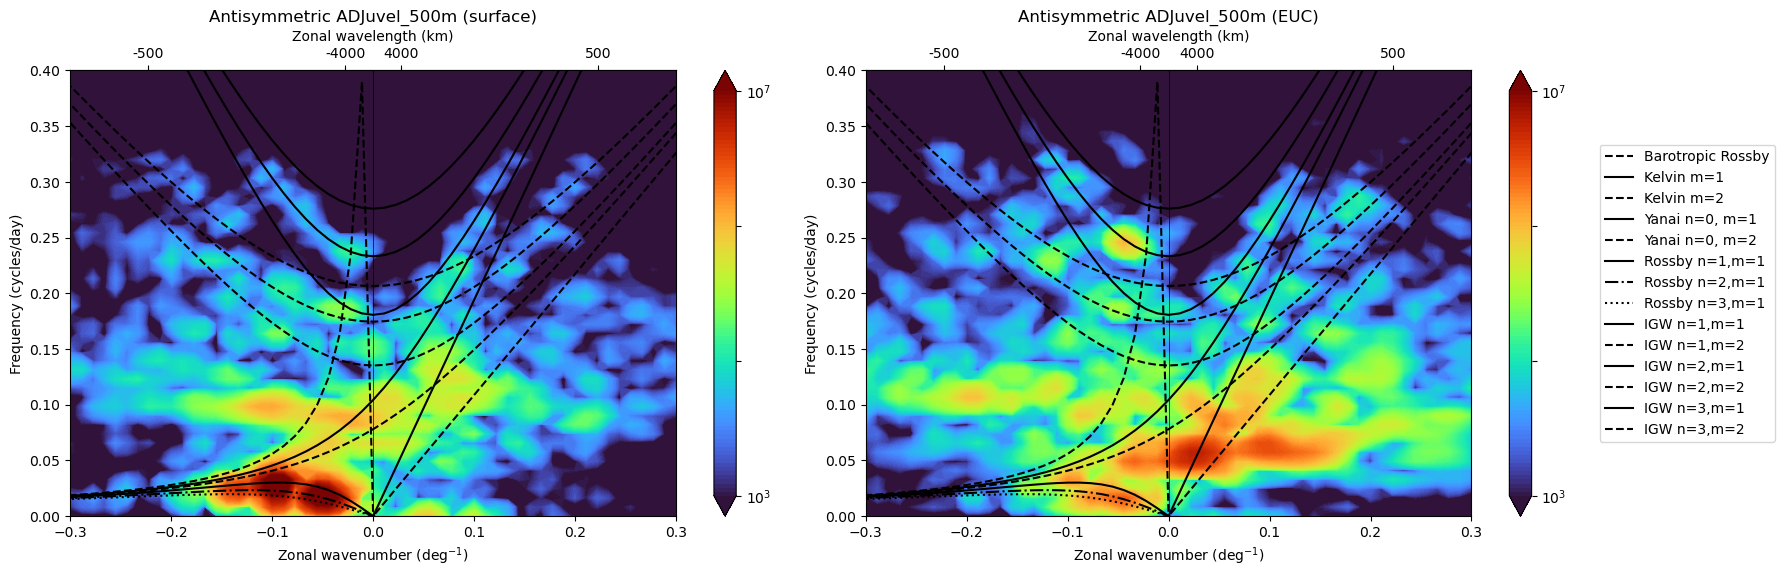

In [227]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s


fig, axes = plt.subplots(figsize=(18,6),ncols=2)
cf = P_da_anti_surf.plot.contourf(ax=axes[0],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)
cf = P_da_anti_EUC.plot.contourf(ax=axes[1],x='kx', y='omega', cmap='turbo',levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

for ax in axes.flatten():
    ax.set_ylabel('Frequency (cycles/day)')
    ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
    # Overlay dispersion curves
    ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='k', linestyle='--', label='Barotropic Rossby')
    ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='k', label='Kelvin m=1')
    ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='k', linestyle='--',label='Kelvin m=2')
    ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='k', label='Yanai n=0, m=1')
    ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='Yanai n=0, m=2')
    ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='Rossby n=1,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', linestyle='-.', label='Rossby n=2,m=1')
    ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', linestyle=':', label='Rossby n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=1,m=1')
    ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=1,m=2')
    ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=2,m=1')
    ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=2,m=2')
    ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='k', label='IGW n=3,m=1')
    ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='k', linestyle='--', label='IGW n=3,m=2')
    ax.axvline(0, color='k',label='_nolabel',lw=0.5)
    # Manually set secondary x-axis ticks
    km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
    kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
    # Set secondary axis manually with fixed tick positions
    secax = ax.secondary_xaxis('top')
    secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
    secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
    secax.set_xlabel('Zonal wavelength (km)')
    ax.set_xlim(-0.3,0.3)
    ax.set_ylim(0,0.4)

axes[0].set_title(f'Antisymmetric ' + fig_str + ' (surface)')
axes[1].set_title(f'Antisymmetric ' + fig_str + ' (EUC)')
axes[1].legend(bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
fig.savefig(foldername + 'k_omega_spectrum_' + fig_str + 'antisymmetric.png', dpi=300)

In [228]:
cluster.close()
client.shutdown()